**CSV** Comma Sepererated Values, virgülle ayrılmış değerler anlamına gelir.

In [43]:
## KUTUPHANELERI YUKLEME VE ICE AKTARMA ##

%pip install pandas  # pandas kütüphanesini yükler
import pandas as pd # pandas'ı projenize dahil eder
import matplotlib.pyplot as plt # görselleştirme için matplotlib'i dahil eder
from sklearn.linear_model import LinearRegression  # linear regression modelini içe aktarır

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#'


PANDAS: Veri analizi ve manipülasyonu için yaygın olarak kullanılan bir kütüphanedir. Veri setini yüklemek, düzenlemek ve analiz yapmak için kullanılır.

MATPLOTLIB: Veri görselleştirme için kullanılan bir kütüphanedir. Grafikler, çizimler, histogramlar ve daha fazlasını oluşturmak için kullanılır.

SCIKIT-LEARN(SKLEARN): Makine öğrenimi ve veri madenciliği için kullanılan bir kütüphanedir. Veri setlerini analiz etmek, sınıflandırma, regresyon, kümeleme gibi görevler için modeller oluşturmak ve eğitmek için yaygın olarak kullanılır. Ayrıca model doğrulama, hiperparametre optimizasyonu ve veri ön işleme gibi işlemler için de araçlar sunar.

sklearn.linear_model: Makine öğrenmesi kütüphanesi olan sklearn'in linear_model modülünü kullanarak doğrusal regresyon modelleri oluşturabilir.

In [44]:
## VERIYI YUKLEME VE ILK INCELEME ##

df = pd.read_csv("reno_clio.csv") # CSV dosyasını okur ve bir DataFrame (df) oluşturur
df.head() # Veri çerçevesinin ilk 5 satırını yazdırır

,yıl,km
0,1996,220.0
1,1996,220.0
2,1996,220.0
3,1996,220.0
4,1996,220.0


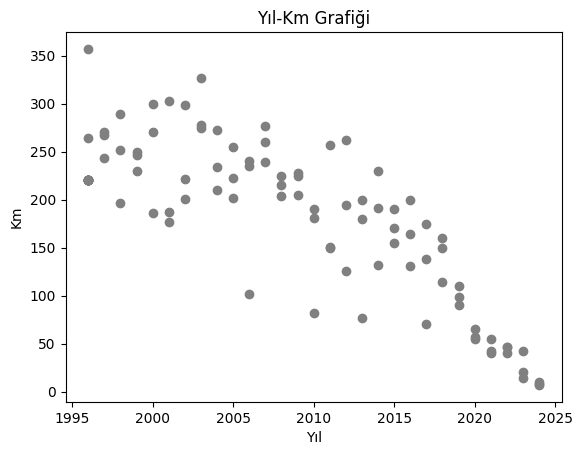

In [45]:
# VERIYI GORSELLESTIRME (GRAFIK CIZME)

# İlk Görselleştirme - Yıl ve Km Arasındaki İlişki

# plt.figure(figsize=(10,6))  # Grafik boyutunu ayarlar

plt.scatter(df["yıl"], df["km"], color="gray")  # Yıl ve Km arasındaki ilişkiyi scatter (dağılım) grafiği ile gösterir
plt.xlabel("Yıl")  # X eksenine etiket ekler
plt.ylabel("Km")  # Y eksenine etiket ekler
plt.title("Yıl-Km Grafiği")  # Grafiğe başlık ekler
plt.show()  # Grafiği ekranda gösterir

In [46]:
# Yeni Bir Sütun Eklemek (Yaş Hesaplama)

# yeni bir sütun ekleyelim, yıl sütunundan 2024 çıkaralım

df["yaş"] = 2024 - df["yıl"] # Yıl sütunundan 2024 çıkararak yaş hesaplanır
df.head()  # Yeni oluşturulan yaş sütunu ile güncellenmiş veriyi görüntüler

,yıl,km,yaş
0,1996,220.0,28
1,1996,220.0,28
2,1996,220.0,28
3,1996,220.0,28
4,1996,220.0,28


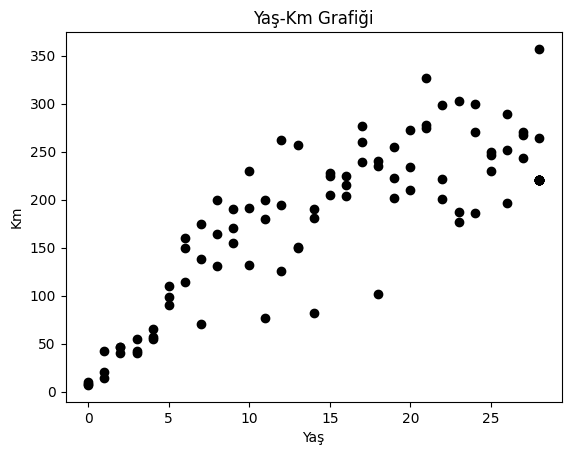

In [47]:
# Yaş ve Km Arasındaki İlişkiyi Görselleştirme

plt.scatter(df["yaş"], df["km"],color="black")
plt.xlabel("Yaş")
plt.ylabel("Km")
plt.title("Yaş-Km Grafiği")
plt.show()

In [48]:
## LINEER REGRESYON MODELI KURMA(MODEL EGITIMI) ##

# En üstte sci-kit learn kütüphanesini import ettiğimiz için şuan burda yapmamıza gerek yok. Ama daha önce import etmediyseniz yapmalısınız.

model = LinearRegression()  # Linear Regression modelini oluşturur


# modelinizi eğitelim
# # Veriyi modelimize veriyoruz (yaş, km). x değişkenimiz yaş, y değişkenimiz km

model.fit(df[["yaş"]],df["km"]) # Modeli yaş (x) ve kilometre (y) verileriyle eğitir

LinearRegression()

LinearRegression(): Doğrusal regresyon modelini oluşturur. Bu model, bir değişkeni (yaş) başka bir değişken (km) ile ilişkilendirerek tahmin yapmamızı sağlar.

model.fit(): Modeli, yaş sütunu (bağımsız değişken) ve km sütunu (bağımlı değişken) ile eğitiriz. Modelin amacı, yaşa göre kilometreyi tahmin etmektir.

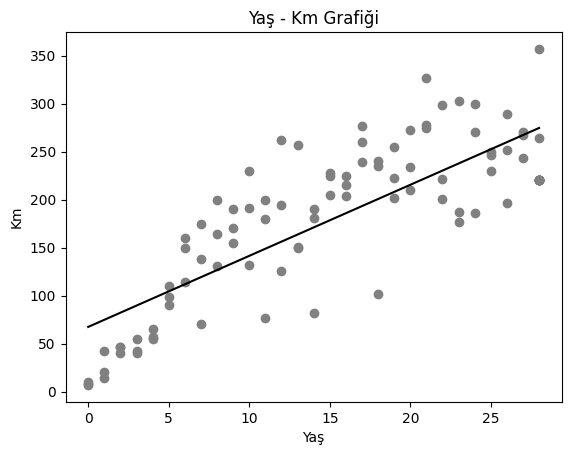

In [49]:
## TAHMIN YAPMA VE GORSELLESTIRME ##
tahmin_edilen_degerler = model.predict(df[["yaş"]]) # Modeli kullanarak tahmin edilen kilometre değerlerini alır
tahmin_edilen_degerler

# şimdi grafiğe çizelim
plt.scatter(df["yaş"], df["km"], color = "gray") # Gerçek veriyi scatter grafikte gösterir
plt.plot(df["yaş"], tahmin_edilen_degerler, color = "black") # Regresyon doğrusu (tahmin edilen değerler) grafikte gösterilir
plt.xlabel("Yaş")
plt.ylabel("Km")
plt.title("Yaş - Km Grafiği")
plt.show()

model.predict(): Modeli, yaşa bağlı kilometreyi tahmin etmek için kullanıyoruz. Bu fonksiyon, eğitim verilerine göre modelin tahmin ettiği kilometre değerlerini döndürür.

plt.plot(): Tahmin edilen kilometre değerlerini gösteren regresyon doğrusu çizilir.

In [50]:
## LINEER REGRESYON FONKSIYONU ##
a = 23
b = 12

def km_tahmini(yas):
    return a * yas + b  # Lineer regresyon fonksiyonu: y = a * x + b

bir_yas_icin_km = km_tahmini(1)  # 1 yaşındaki araba için tahmin yapalım
print(bir_yas_icin_km)  # Tahmini kilometreyi yazdırır

35


Burada lineer regresyon formülünü manuel olarak yazıyoruz: y = a * x + b. a eğim (slope), b ise y-kesişimidir.

km_tahmini() fonksiyonu, yaşa bağlı olarak kilometreyi tahmin eder.

In [51]:
## RASGELE SAYILARLA MODELI EĞİTELİM (BAŞKA BİR ÖRNEK) ##

# Modeli daha basit verilere göre eğitelim
model.fit([[1], [2], [3], [4]], [5, 9, 13, 17])


LinearRegression()

Linear regression (doğrusal regresyon) modelini daha basit rasgele verilere göre eğitiyoruz.
model.fit() fonksiyonu, modelin parametrelerini öğrenmesi için verilerle eğitilmesini sağlar.

İlk parametre: [[1], [2], [3], [4]] — Bu, bağımsız değişkenler yani girdi verileridir. Bu örnekte, x değeri olarak kullanacağımız 4 veri noktasıdır. Bu veriler, modelimize verilen özellikler ya da input verileridir. Bu durumda, bunlar [1], [2], [3], [4] gibi tek bir sayıyı temsil eden liste elemanlarıdır.

İkinci parametre: [5, 9, 13, 17] — Bu da bağımlı değişkenler yani çıktı verileridir. Bu, modelin tahmin etmeye çalışacağı sonuçlardır. Yani, x = 1 olduğunda y = 5, x = 2 olduğunda y = 9, vb. Bu değerler, x değerlerinin karşılık geldiği doğru sonuçlardır.

In [52]:
# modelimizin parametrelerini görelim
# model.coef_, model.intercept_ şeklinde de yazabiliriz. Aşağıdaki gibi de yazabiliriz.

print("Modelin katsayıları (a):", model.coef_)  # Modelin eğimi (slope)
print("Modelin y-kesişimi (b):", model.intercept_)  # Modelin y-kesişimi

Modelin katsayıları (a): [4.]
Modelin y-kesişimi (b): 0.9999999999999964


model.coef_: Modelin eğimi (slope) olan a parametresini verir.
model.intercept_: Y-kesişimi olan b parametresini verir.

In [53]:
# # Modeli kullanarak tahmin yapma predict 1
model.predict([[1]])

array([5.])

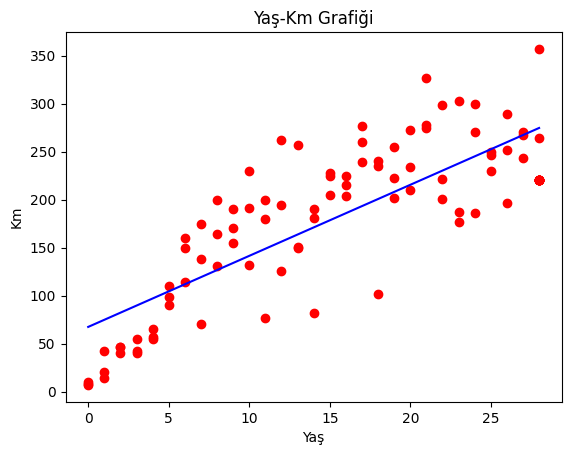

In [54]:
# şimdi grafiğe çizelim
plt.scatter(df["yaş"], df["km"], color="red")
plt.plot(df["yaş"], tahmin_edilen_degerler, color="blue")
plt.xlabel("Yaş")
plt.ylabel("Km")
plt.title("Yaş-Km Grafiği")
plt.show()

In [55]:
## MODEL KAYBINI VE BAŞARI DUZEYINI (R² Skoru) GORME ##
#  get model loss

model.score(df[["yaş"]], df["km"]) # Model kaybını (score) hesaplar
print("Model Skoru (R^2):", model.score)  # Modelin başarısını gösterir (1'e yakın değer iyi bir modeldir)

Model Skoru (R^2): <bound method RegressorMixin.score of LinearRegression()>


c:\Users\MSI-NB\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


model.score(): Bu fonksiyon, modelin ne kadar başarılı olduğunu ölçer. R² skoru, modelin veriyi ne kadar iyi açıkladığını gösterir. 
1'e yakın bir R² skoru, modelin veriyi çok iyi açıkladığını gösterir. 
Yani model başarılıdır.

In [56]:
# Yeni Bir Tahmin Yapma (12 Yaşındaki Araba İçin)

oniki_yasindaki_araba = model.predict([[12]])  # 12 yaşındaki araç için tahmin yapalım
print(oniki_yasindaki_araba)  # Tahmin edilen kilometreyi yazdırır

[49.]


In [57]:
df.head(65).tail(15)

,yıl,km,yaş
50,2009,205.0,15
51,2009,225.0,15
52,2010,190.0,14
53,2010,82.0,14
54,2010,181.0,14
55,2011,151.0,13
56,2011,257.0,13
57,2011,150.0,13
58,2012,262.0,12
59,2012,126.0,12


In [58]:
## VERI MANIPULASYONU VE LINEER REGRESYON FONKSIYONU ##

a = 8.65829228
b = 56.11724137931033

# Linear Regression Modeli
def tahmin_et(x):
  y = a * x + b   # Manuel lineer regresyon fonksiyonu
  return y

In [59]:
bes_yas_icin_km = tahmin_et(5)  # 5 yaşındaki araç için tahmin yapalım
print(bes_yas_icin_km)  # Tahmin edilen kilometreyi yazdırır

99.40870277931032


In [60]:
# Market basket analysis
# Association rule learning (birliktelik kuralı öğrenme)

In [61]:
## LOJISTIK REGRESYON MODELI FONKSIYONU ##

a1 = 0.5
a2 = 0.15
a3 = 0.25
a4 = 0.1
a5 = 0.1
b = 0.1

# Tek bir değişken alan ve bir değer döndüren bir fonksiyon
def lojistik_regresyon(x):
  y = a1 * x + a2 * x + a3 * x + a4 * x + a5 * x + b
  return y

def lojistik_regresyon2(x1, x2, x3, x4, x5):
  y = a1 * x1 + a2 * x2 + a3 * x3 + a4 * x4 + a5 * x5 + b
  return y

Lojistik regresyon, genellikle ikili sınıflandırma problemlerinde kullanılır. Ancak buradaki fonksiyon, aslında bir lineer regresyon fonksiyonu gibi davranıyor. 

Lojistik regresyon burada kullanılan parametreler (a1, a2, a3, a4, a5 ve b), genellikle doğrusal bir ilişkiyi tanımlar. Bu fonksiyonlar, bağımsız değişkenlerin (x) lineer kombinasyonlarıyla bir bağımlı değişkeni (y) tahmin eder. Ancak aslında burada kullanılan bir lineer regresyon formülüdür.

lojistik_regresyon(x) fonksiyonu, tek bir bağımsız değişkenle (x) bir değer döndürür.
lojistik_regresyon2(x1, x2, x3, x4, x5) fonksiyonu ise birden fazla bağımsız değişkeni alır ve bunların lineer kombinasyonu ile bir değer döndürür.

In [62]:
## LINEER REGRESYON MODELI PARAMETRELERINI KUTUPHANE KULLANMADAN OLUSTURALIM ##

# Kütüphane kullanmadan lineer regresyon parametrelerini hesaplama
# a (eğim), covariance (x, y) ile variance (x) arasındaki oran olarak hesaplanır.

def a_ve_b_eyi_bul(x, y):
  a = sum((x - x.mean()) * (y - y.mean())) / sum((x - x.mean()) ** 2)
  b = y.mean() - a * x.mean()
  return a, b

a, b = a_ve_b_eyi_bul(df["yaş"], df["km"])
print(a, b)

7.401501477832516 67.42835862068958


In [63]:
## LINEER REGRESYON MODELI PARAMETRELERINI ADIM ADIM (DETAYLI) HESAPLAMA ##

def a_ve_b_eyi_bul_detay(yaslar, kmler):
  
  yas_top = 0
  km_top = 0

  for i in range(len(yaslar)):
    yas_top = yas_top + yaslar[i]
    km_top = km_top + kmler[i]

  yas_ort = yas_top / len(yaslar)  # Yaşların ortalamasını hesapla
  km_ort = km_top / len(kmler)    # Km'lerin ortalamasını hesapla

  yas_fark = 0
  km_fark = 0

  for i in range(len(yaslar)):
    yas_fark = yas_fark + (yaslar[i] - yas_ort) * (kmler[i] - km_ort) # Kovaryans
    km_fark = km_fark + (yaslar[i] - yas_ort) ** 2 # Varyans
    
  a = yas_fark / km_fark  # Eğim (a)
  b = km_ort - a * yas_ort  # Y-kesişimi (b)

  return a, b

a, b = a_ve_b_eyi_bul_detay(df["yaş"], df["km"])
print(a, b)


7.401501477832516 67.42835862068958
